In [37]:
#Downloading Libraries

In [38]:
!pip install textblob --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries downloaded successfully!")

Libraries downloaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/aimeerim/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/aimeerim/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/aimeerim/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [39]:
#reading the dataset

In [40]:
df = pd.read_excel('../data/depression-data-set-kaggle.xlsx')
print("📊 Data Set Size:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
print("\n🔍 The first 5 rows:")
print(df.head())
print("Dataset loaded successfully!")

📊 Data Set Size: (7489, 5)

📋 Columns: ['text', 'label', 'Age', 'Gender', 'Age Category']

🔍 The first 5 rows:
                                                text  label   Age  Gender  \
0                               let Gather For Party    0.0  16.0    Male   
1    I hate being alive when I feel so dead inside.     1.0  17.0  Female   
2  Exam are Comimg I  m already  Feeling Very Dep...    1.0  16.0    Male   
3                                       Nice picture    0.0  16.0    Male   
4  Feeling worried, even though you actually have...    1.0  16.0    Male   

  Age Category  
0     Teen Age  
1     Teen Age  
2     Teen Age  
3     Teen Age  
4     Teen Age  
Dataset loaded successfully!


In [41]:
#General Information about the dataset
print("📊 Dataset Size:", df.shape)

print("\n📋 Column Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🏷️ Label Distribution:")
print(df['label'].value_counts())

📊 Dataset Size: (7489, 5)

📋 Column Types:
text             object
label           float64
Age             float64
Gender           object
Age Category     object
dtype: object

❓ Missing Values:
text            13
label            3
Age              3
Gender           3
Age Category     3
dtype: int64

🏷️ Label Distribution:
label
0.0    6259
1.0    1227
Name: count, dtype: int64


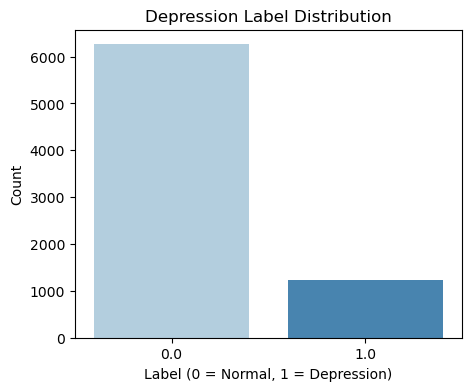

In [42]:
# Label distribution visualization
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Blues')

plt.title('Depression Label Distribution')
plt.xlabel('Label (0 = Normal, 1 = Depression)')
plt.ylabel('Count')

plt.show()

In [43]:
# Remove missing values
df = df.dropna(subset=['text', 'label'])

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Dataset size after cleaning:", df.shape)

Dataset size after cleaning: (7476, 5)


In [44]:
# Expand keyword lists
def get_severity_v3(row):
    text = str(row['text']).lower()
    label = row['label']

    severe_words = ['hopeless', 'suicide', 'die', 'kill', 'worthless',
                    'end my life', 'give up', 'no reason to live',
                    'cant go on', 'nothing matters', 'want to disappear']

    moderate_words = ['depressed', 'anxious', 'lonely', 'sad', 'crying',
                      'empty', 'tired', 'exhausted', 'miserable', 'lost',
                      'broken', 'hurt', 'pain', 'suffer', 'struggle']

    mild_words = ['stress', 'worried', 'nervous', 'upset', 'confused',
                  'unhappy', 'disappointed', 'frustrated', 'overwhelmed',
                  'exam', 'pressure', 'difficult', 'hard time']

    if label == 1.0:
        if any(w in text for w in severe_words):
            return 'Severe'
        elif any(w in text for w in moderate_words):
            return 'Moderate'
        else:
            return 'Mild'
    else:
        if any(w in text for w in mild_words):
            return 'Mild'
        else:
            return 'Minimal'

df['severity_v3'] = df.apply(get_severity_v3, axis=1)

print("🏷️ New Severity Distribution:")
print(df['severity_v3'].value_counts())

🏷️ New Severity Distribution:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64


In [45]:
#Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove non-letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

print("Preprocessing completed!")
print("\nExample original text:")
print(df['text'][0])
print("\nCleaned text:")
print(df['clean_text'][0])

Preprocessing completed!

Example original text:
let Gather For Party

Cleaned text:
let gather party


In [46]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

# TF-IDFf
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['severity_v3']

print("Class distribution before SMOTE:")
print(y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nClass distribution after SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())

Class distribution before SMOTE:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64

Class distribution after SMOTE:
severity_v3
Minimal     6115
Mild        6115
Moderate    6115
Severe      6115
Name: count, dtype: int64


In [47]:
# After SMOTE, we can split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Train/Test Split are completed!")
print(f"Training set: {X_train.shape}")
print(f"Test set  : {X_test.shape}")

Train/Test Split are completed!
Training set: (19568, 5000)
Test set  : (4892, 5000)


In [48]:
# Now we can train a Logistic Regression model on the resampled data.
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training is completed!")
print(f"\nClasses: {model.classes_}")

Model training is completed!

Classes: ['Mild' 'Minimal' 'Moderate' 'Severe']


In [49]:
def predict_severity(text):
    clean = preprocess_text(text)
    vector = tfidf.transform([clean])
    
    prediction = model.predict(vector)[0]
    probs = model.predict_proba(vector)[0]
    
    print(f"Text: {text}")
    print(f"Predicted Severity: {prediction}")
    print(f"Confidence: {max(probs):.2f}")

In [50]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Mild', 'Minimal', 'Moderate', 'Severe']))

Accuracy: 0.9581

Classification Report:
              precision    recall  f1-score   support

        Mild       0.97      0.88      0.92      1223
     Minimal       0.89      0.95      0.92      1223
    Moderate       0.98      1.00      0.99      1223
      Severe       0.99      1.00      0.99      1223

    accuracy                           0.96      4892
   macro avg       0.96      0.96      0.96      4892
weighted avg       0.96      0.96      0.96      4892



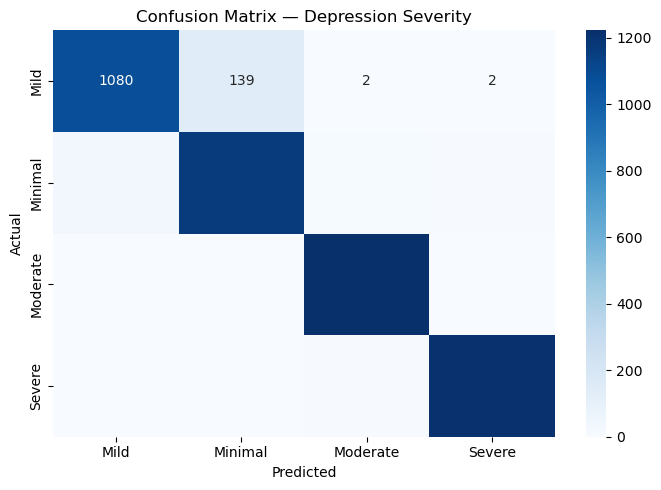

In [51]:
# Confusion Matrix Visualization
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred,
                      labels=['Mild','Minimal','Moderate','Severe'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mild','Minimal','Moderate','Severe'],
            yticklabels=['Mild','Minimal','Moderate','Severe'])
plt.title('Confusion Matrix — Depression Severity')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [55]:
# Yeni bir metin ile tahmin yap
def predict_severity(text):
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    proba = model.predict_proba(vectorized)[0]
    classes = model.classes_

    print(f"📝 Metin     : {text}")
    print(f"🎯 Tahmin    : {prediction}")
    print(f"\n📊 Olasılıklar:")
    for cls, prob in zip(classes, proba):
        print(f"   {cls:10s}: {prob:.4f}")

# # Test et
predict_severity("I feel so hopeless and tired all the time, nothing makes me happy")
print("\n" + "─"*50 + "\n")
predict_severity("I had a great day today, feeling wonderful!")
print("\n" + "─"*50 + "\n")
predict_severity("Exams are coming, I am already feeling very depressed")
print("\n" + "─"*50 + "\n")
predict_severity("Exams are coming, I am already feeling very depressed, i want to die")

# test_metinler = [
#     "I want to end my life, there is no point anymore",
#     "I am feeling a bit stressed about my homework",
#     "Today was amazing, I feel so happy and energetic!",
#     "I cry every night, I feel so empty and broken",
#     "I failed my exam and I am worried about my grades"
# ]

# print("=" * 55)
# for metin in test_metinler:
#     predict_severity(metin)
#     print("─" * 55)

📝 Metin     : I feel so hopeless and tired all the time, nothing makes me happy
🎯 Tahmin    : Moderate

📊 Olasılıklar:
   Mild      : 0.0723
   Minimal   : 0.2566
   Moderate  : 0.6352
   Severe    : 0.0359

──────────────────────────────────────────────────

📝 Metin     : I had a great day today, feeling wonderful!
🎯 Tahmin    : Minimal

📊 Olasılıklar:
   Mild      : 0.1366
   Minimal   : 0.5885
   Moderate  : 0.2182
   Severe    : 0.0566

──────────────────────────────────────────────────

📝 Metin     : Exams are coming, I am already feeling very depressed
🎯 Tahmin    : Moderate

📊 Olasılıklar:
   Mild      : 0.0990
   Minimal   : 0.0116
   Moderate  : 0.8760
   Severe    : 0.0134

──────────────────────────────────────────────────

📝 Metin     : Exams are coming, I am already feeling very depressed, i want to die
🎯 Tahmin    : Severe

📊 Olasılıklar:
   Mild      : 0.0041
   Minimal   : 0.0023
   Moderate  : 0.0553
   Severe    : 0.9383
